## Playing around with attendance data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt

cities = pd.read_csv("../data/cities.csv")

# I'm going to assume "trip" == "event"
sites = pd.read_csv("../data/sites.csv", index_col="siteId")
cities = pd.read_csv("../data/cities.csv")
events = pd.read_csv("../data/events.csv")

eventHistory = pd.merge(sites, events, on="siteId")
eventHistory = pd.merge(eventHistory, cities, on="city")



# Remove nans for city and site type 
eventHistory = eventHistory.dropna(subset=["city", "siteType"])

# Split multi-valued items
eventHistory["siteType"] = eventHistory["siteType"].apply(lambda st : np.array(st.split(";")) )
eventHistory["siteTypePretty"] = eventHistory["siteType"].apply(lambda st : ", ".join(st) )

display(eventHistory)



,siteId,siteName,siteType,city,eventId,date,footTraffic,lat,long,pop,svi,siteTypePretty
0,0,Mercy Thrift Store,[Thrift store],Lima,0,2024-08-06 00:00:00,1,40.746389,-84.123333,35579,0.923333,Thrift store
1,0,Mercy Thrift Store,[Thrift store],Lima,19,2024-10-01 00:00:00,3,40.746389,-84.123333,35579,0.923333,Thrift store
2,0,Mercy Thrift Store,[Thrift store],Lima,31,2024-11-05 00:00:00,0,40.746389,-84.123333,35579,0.923333,Thrift store
3,0,Mercy Thrift Store,[Thrift store],Lima,41,2024-12-03 00:00:00,0,40.746389,-84.123333,35579,0.923333,Thrift store
4,0,Mercy Thrift Store,[Thrift store],Lima,50,2024-01-07 00:00:00,2,40.746389,-84.123333,35579,0.923333,Thrift store
...,...,...,...,...,...,...,...,...,...,...,...,...
104,21,Delphos Senior Center,[Senior community],Delphos,63,2025-02-12 00:00:00,7,40.861111,-84.350000,7117,0.562500,Senior community
105,22,Restore,[Thrift store],Lima,77,2025-03-06 00:00:00,3,40.746389,-84.123333,35579,0.923333,Thrift store
106,22,Restore,[Thrift store],Lima,91,2025-04-03 00:00:00,3,40.746389,-84.123333,35579,0.923333,Thrift store
107,22,Restore,[Thrift store],Lima,102,2024-05-01 00:00:00,9,40.746389,-84.123333,35579,0.923333,Thrift store


## Helper functions

In [2]:
def remove_special_events(events):

    no_special_events_mask = np.logical_not(events["siteType"].apply(lambda t : (t == "Special Event").all()))
    return events.loc[no_special_events_mask,:]



def plot_site_scatter(events, filter_value=None, legend=True, group_attr="siteName", x_var="pop"):

    events = remove_special_events(events)

    if filter_value != None: 
        site_type_mask = events["siteType"].apply(lambda t : (t == filter_value).any())
        events = events.loc[site_type_mask,:]

    site_set = set(events[group_attr])

    fig, ax = plt.subplots()

    for site in site_set:
        x = events.loc[events[group_attr] == site, x_var]
        y = events.loc[events[group_attr] == site,"footTraffic"]

        current_city = events.loc[events[group_attr] == site,"city"].values[0]

        label = f"{site}"
        ax.scatter(x, y, label=label)

    if legend:
        plt.legend(loc="center left", bbox_to_anchor=(1,0.5))

    if filter_value is not None:
        plt.title(f"Expected attendance at {filter_value} sites")
    else:
        plt.title(f"Expected attendance across all sites")

    ax.set_xlabel(x_var)
    ax.set_ylabel("footTraffic")
    fig.set_size_inches(8, 5)

    return ax

## Examining attenance as a function of population and site type
_Reflections_: It doesn't seem that population is a big determinant of expected attendance 

<Axes: title={'center': 'Expected attendance at Library sites'}, xlabel='pop', ylabel='footTraffic'>

<Axes: title={'center': 'Expected attendance at Thrift store sites'}, xlabel='pop', ylabel='footTraffic'>

<Axes: title={'center': 'Expected attendance at Charitable Meal sites'}, xlabel='pop', ylabel='footTraffic'>

<Axes: title={'center': 'Expected attendance at Senior community sites'}, xlabel='pop', ylabel='footTraffic'>

<Axes: title={'center': 'Expected attendance at Gym sites'}, xlabel='pop', ylabel='footTraffic'>

<Axes: title={'center': 'Expected attendance at Church sites'}, xlabel='pop', ylabel='footTraffic'>

<Axes: title={'center': 'Expected attendance at Food pantry sites'}, xlabel='pop', ylabel='footTraffic'>

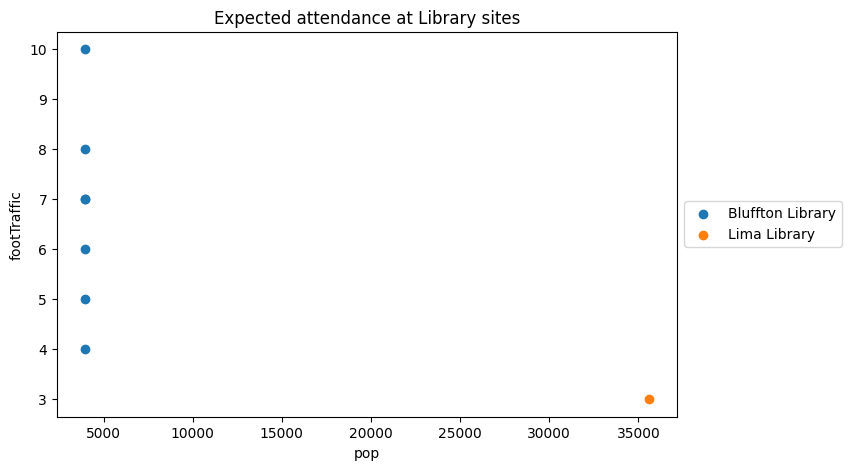

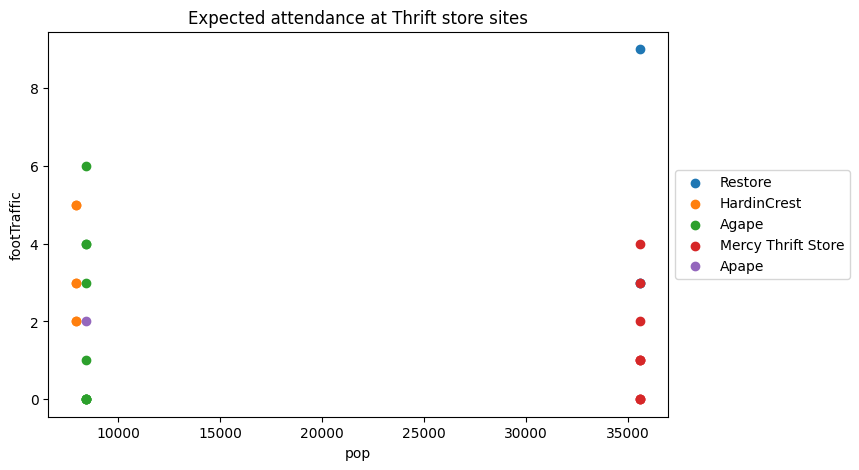

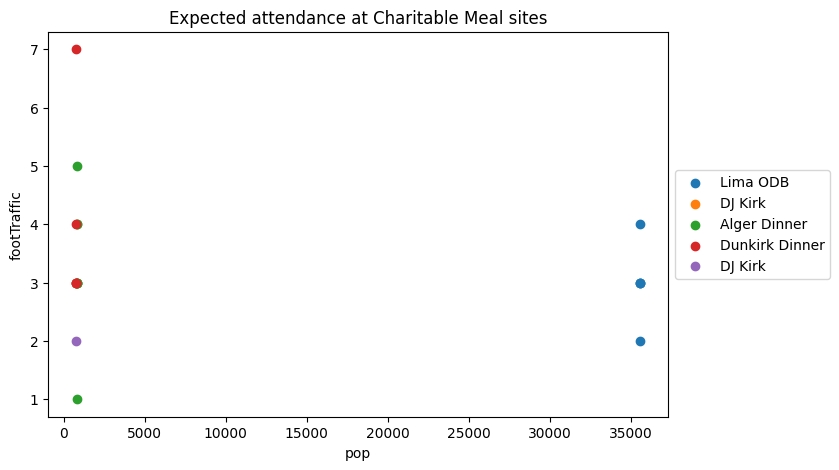

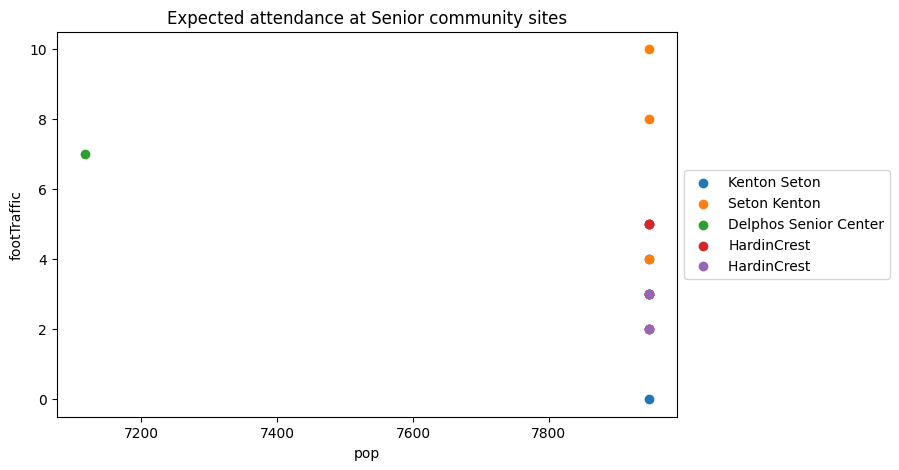

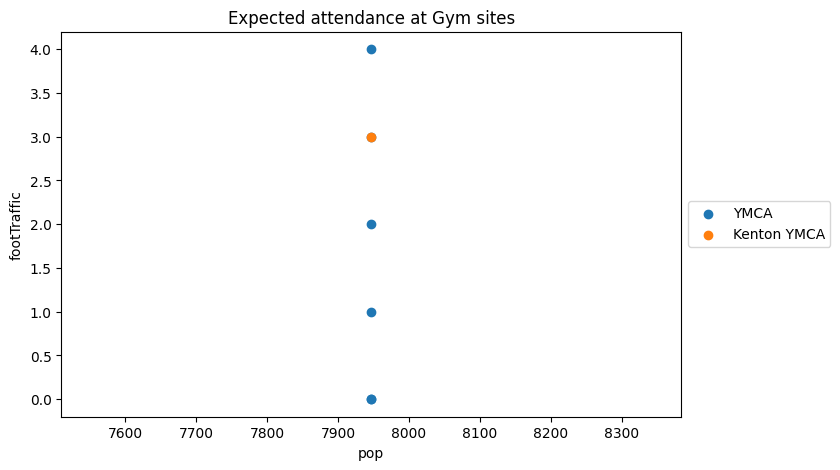

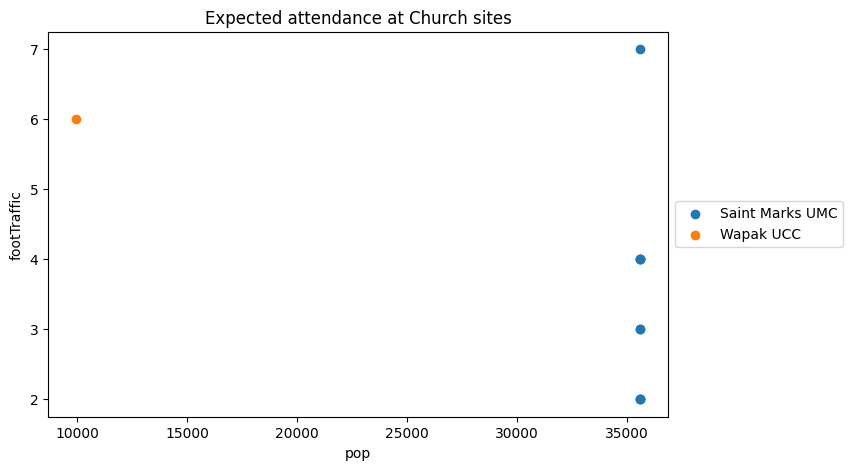

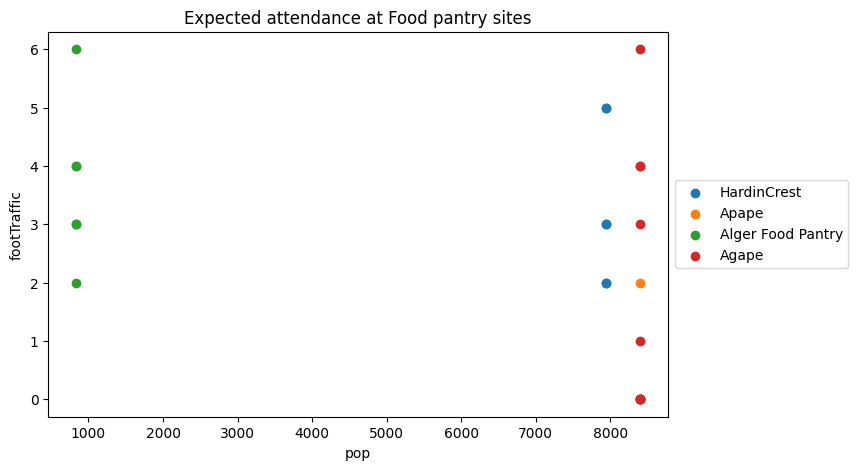

In [3]:
ax = plot_site_scatter(eventHistory, filter_value="Library")
display(ax)

ax = plot_site_scatter(eventHistory, filter_value="Thrift store")
display(ax)

ax = plot_site_scatter(eventHistory, filter_value='Charitable Meal')
display(ax)

ax = plot_site_scatter(eventHistory, filter_value="Senior community")
display(ax)

ax = plot_site_scatter(eventHistory, filter_value="Gym")
display(ax)

ax = plot_site_scatter(eventHistory, filter_value="Church")
display(ax)

ax = plot_site_scatter(eventHistory, "Food pantry")
display(ax)

## Examining attendance as a function of population
_Reflections:_ It looks like population really isn't a big determinant of expected attendance 

<Axes: title={'center': 'Expected attendance across all sites'}, xlabel='Population of city', ylabel='footTraffic'>

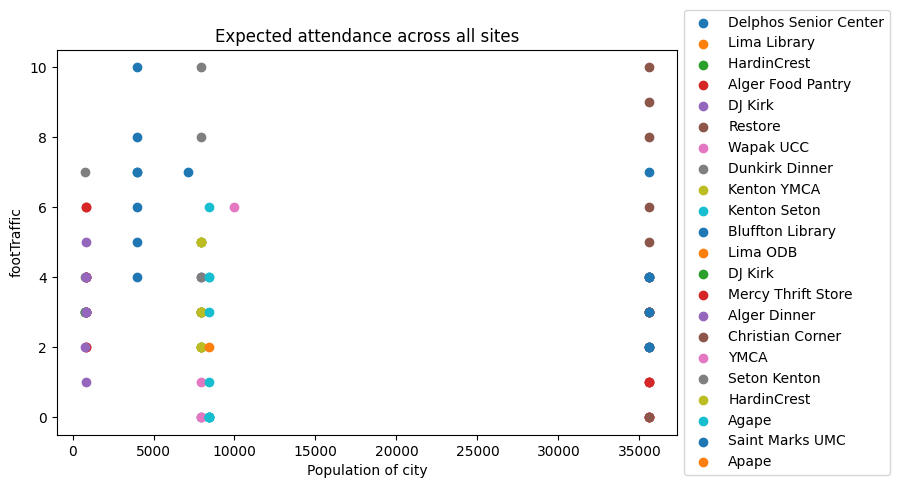

In [4]:
events_no_special = remove_special_events(eventHistory)
ax = plot_site_scatter(events_no_special, legend=True, group_attr="siteName")
ax.set_xlabel("Population of city")
display(ax);

Text(0.5, 0, 'Population of city')

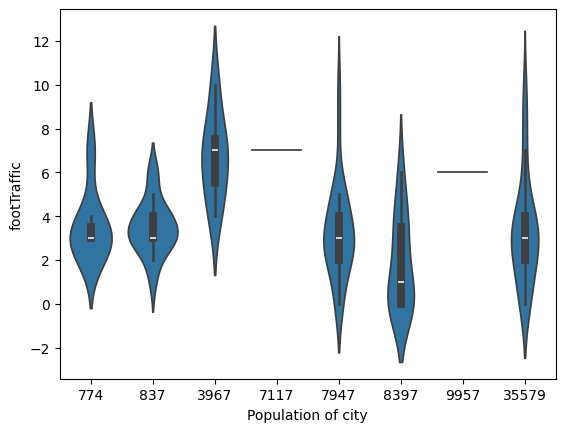

In [5]:
import seaborn as sns

ax = sns.violinplot(data=events_no_special, x="pop", y="footTraffic")
ax.set_xlabel("Population of city")

## Examining event type versus attendance

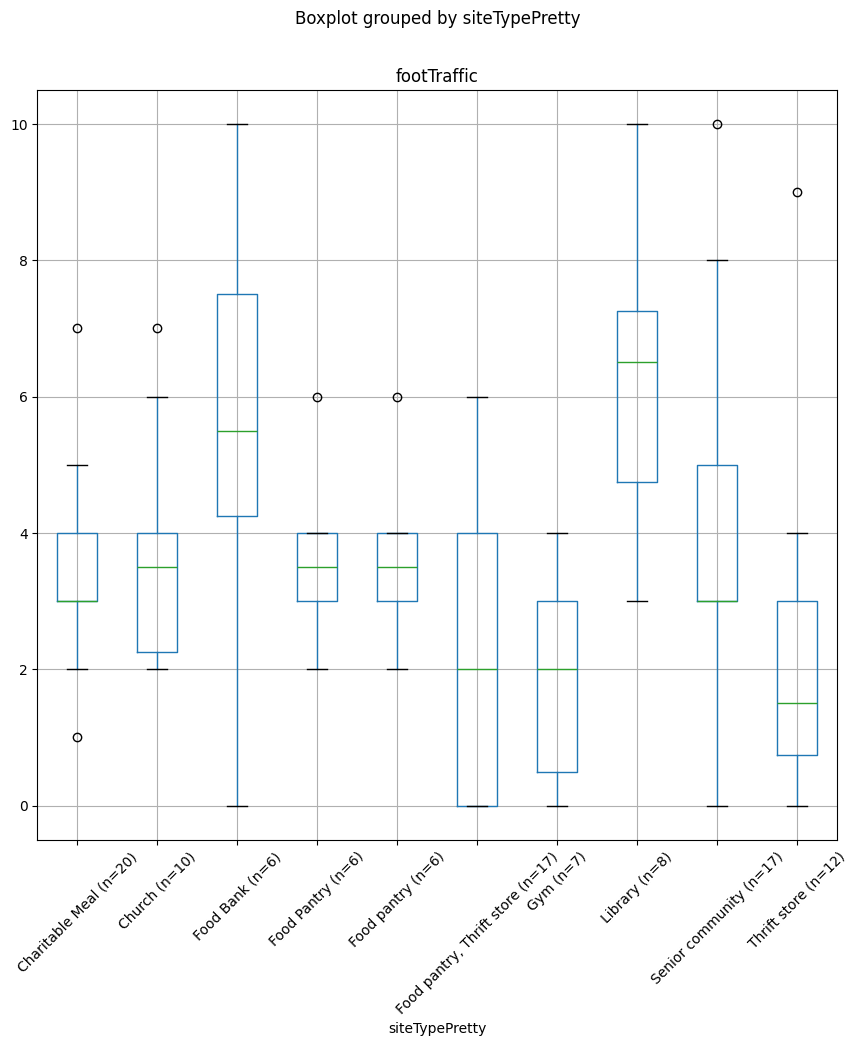

In [6]:

counts = events_no_special['siteTypePretty'].value_counts()
new_labels = [f"{label} (n={counts[label]})" for label in counts.index]
ax = events_no_special.boxplot(column="footTraffic", by="siteTypePretty", figsize=(10,10), rot=45)
new_labels.sort()
ax.set_xticklabels(new_labels);


## Examining city versus attendance

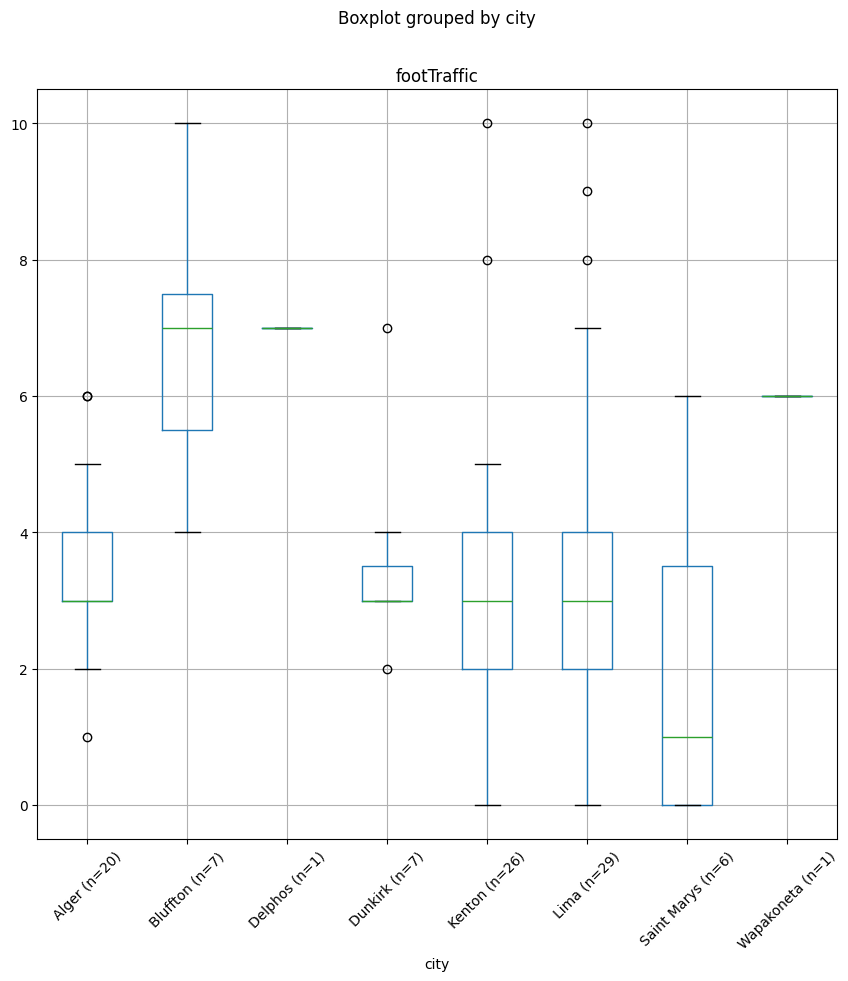

In [7]:
counts = events_no_special.loc[events_no_special["footTraffic"] > 0, 'city'].value_counts()
new_labels = [f"{label} (n={counts[label]})" for label in counts.index]
new_labels.sort()
ax = events_no_special.boxplot(column="footTraffic", by="city", figsize=(10,10),rot=45)
ax.set_xticklabels(new_labels);

## Corellation analysis
... yes I realize the city values and the types doesn't make much sense. But meh. 
_Reflection:_ But!! Population size and foot traffic are very uncorrelated 

C:\Users\i-kropp\AppData\Local\Temp\ipykernel_22468\2869316148.py:13: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  numbery_events = numbery_events.replace({"city" : city_dict,


,footTraffic,siteTypePretty,pop,city,siteName
footTraffic,1.000000,-0.281318,-0.074200,0.324926,-0.165051
siteTypePretty,-0.281318,1.000000,0.172894,-0.311684,0.041022
pop,-0.074200,0.172894,1.000000,-0.586661,0.250953
city,0.324926,-0.311684,-0.586661,1.000000,-0.566303
siteName,-0.165051,0.041022,0.250953,-0.566303,1.000000


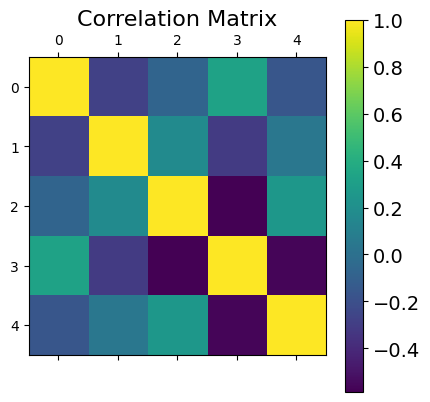

In [8]:
def dictionize_df(df, attr): 
    discrete_vals = set(df.loc[:,attr].values)
    dictionary = {value: number for (number, value) in enumerate(discrete_vals)}
    return dictionary


city_dict = dictionize_df(eventHistory, "city")
loca_dict = dictionize_df(eventHistory, "siteName")
type_dict = dictionize_df(eventHistory, "siteTypePretty")

attributes = ["footTraffic", "siteTypePretty", "pop", "city", "siteName"]
numbery_events = events_no_special.loc[:,attributes]
numbery_events = numbery_events.replace({"city" : city_dict, 
                                         "siteName": loca_dict,
                                         "siteTypePretty" : type_dict})


corr_mat = numbery_events.corr()
display(corr_mat)

plt.matshow(corr_mat)
cb = plt.colorbar()
cb.ax.tick_params(labelsize=14)
plt.title('Correlation Matrix', fontsize=16);
plt.show()

